In [1]:
import networkx as nx
import matplotlib.pyplot as plt

Task 1.1: Create Different Types of Graphs
Create two un-directed graphs: one with 8 nodes and 10 edges, and another with 12 nodes and 11 edges.

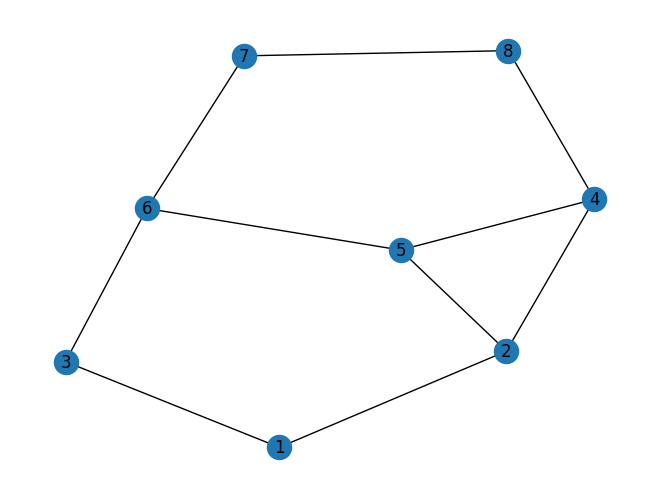

In [ ]:
G1 = nx.Graph()
G1.add_nodes_from([1,2,3,4,5,6,7,8])
G1.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (2, 5),
    (3, 6),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (4, 8)
])

nx.draw(G1, with_labels=True)

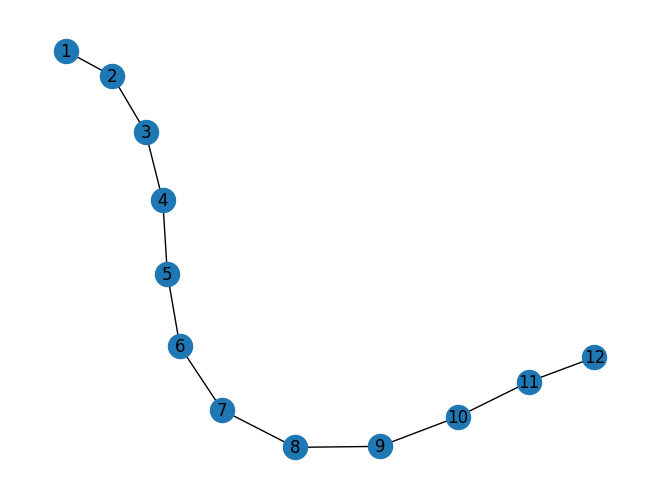

In [11]:
G2 = nx.Graph()
G2.add_nodes_from([1,2,3,4,5,6,7,8,9,10,11,12])
G2.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (8, 9),
    (9, 10),
    (10, 11),
    (11, 12)
])
nx.draw(G2, with_labels=True)

Task 1.2: Graph Properties Analysis
For each graph created above, calculate and display the number of nodes and edges and their degree. 

In [16]:
print("Number of nodes in G1:", G1.number_of_nodes())
print("Number of edges in G1:", G1.number_of_edges())
print("Number of nodes in G2:", G2.number_of_nodes())
print("Number of edges in G2:", G2.number_of_edges())
# print("Degree of G1:", G1.degree())
# print("Degree of G2:", G2.degree())

Number of nodes in G1: 8
Number of edges in G1: 10
Number of nodes in G2: 12
Number of edges in G2: 11


In [18]:
print("Degrees of nodes in G1:")
for node,degree in G1.degree():
    print(f"Node {node} has degree {degree}")

Degrees of nodes in G1:
Node 1 has degree 2
Node 2 has degree 3
Node 3 has degree 2
Node 4 has degree 3
Node 5 has degree 3
Node 6 has degree 3
Node 7 has degree 2
Node 8 has degree 2


In [19]:
print("Degrees of nodes in G2:")
for node,degree in G2.degree():
    print(f"Node {node} has degree {degree}")

Degrees of nodes in G2:
Node 1 has degree 1
Node 2 has degree 2
Node 3 has degree 2
Node 4 has degree 2
Node 5 has degree 2
Node 6 has degree 2
Node 7 has degree 2
Node 8 has degree 2
Node 9 has degree 2
Node 10 has degree 2
Node 11 has degree 2
Node 12 has degree 1


Task 1.3: Self-Loop and Multi-Edge Handling
Create a graph with self-loops
Create a multigraph with multiple edges between same nodes

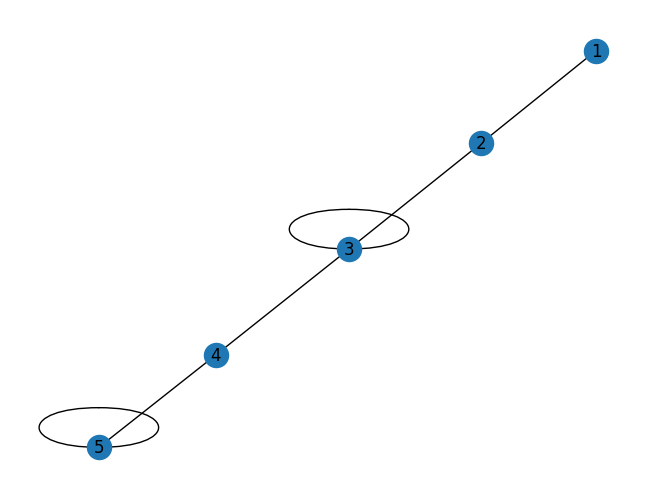

In [21]:
G_loop = nx.Graph()
G_loop.add_nodes_from([1,2,3,4,5])
G_loop.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 3), 
    (3, 4),
    (4, 5),
    (5, 5)   
])
nx.draw(G_loop, with_labels=True)

5


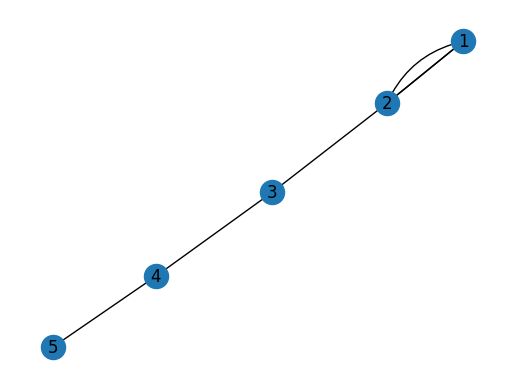

In [77]:
import networkx as nx
import matplotlib.pyplot as plt

G_Multi = nx.MultiGraph()

G_Multi.add_nodes_from([1, 2, 3, 4, 5])

G_Multi.add_edges_from([
    (1, 2),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5)
])

pos = nx.spring_layout(G_Multi)

nx.draw_networkx_edges(
    G_Multi,
    pos,
    edgelist=[(1, 2)],
    connectionstyle="arc3,rad=0.25"
)

nx.draw(G_Multi,pos, with_labels=True)

print(G_Multi.number_of_edges())


Task 1.4: Connectivity Analysis
Create a disconnected graph with 5 separate components and visualize each connected component separately

Connected components in G_Disconn: [{1, 2}, {3, 4, 5}, {6, 7}, {8, 9, 10, 11}, {12, 13, 14, 15, 16}]
Number of connected components in G_Disconn: 5


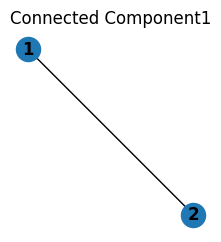

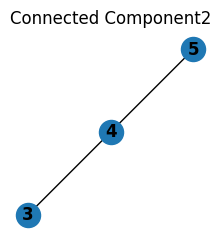

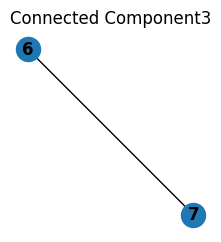

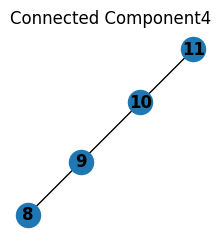

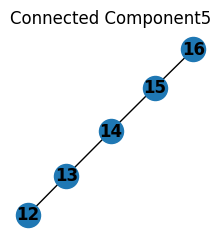

In [94]:
G_Disconn= nx.Graph()
G_Disconn.add_edges_from([
    (1, 2),
    (3, 4),(4, 5),
    (6, 7),
    (8,9),(9,10),(10,11),
    (12,13),(13,14),(14,15),(15,16)
])
components = list(nx.connected_components(G_Disconn))
print("Connected components in G_Disconn:", components)
print("Number of connected components in G_Disconn:", len(components))

for i, component in enumerate(components):
  subgraph=G_Disconn.subgraph(component)
  plt.figure(figsize=(2,2))
  nx.draw(subgraph, with_labels=True, font_weight='bold')
  plt.title(f"Connected Component{i+1}")

Task 1.5: Component Manipulation
Start with a connected graph
Systematically remove nodes/edges to create disconnected components
Track how connectivity changes after each removal

Is connected: True
Number of connected components: 1
Connected components: [{1, 2, 3, 4, 5, 6, 7, 8}]


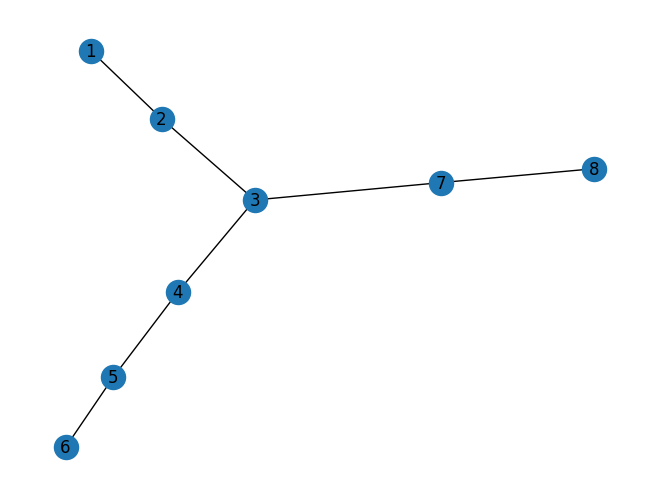

In [100]:
G_connected = nx.Graph()

G_connected.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (3, 7),
    (7, 8)
])

def check_connectivity(G):
    print("Is connected:", nx.is_connected(G))
    print("Number of connected components:", nx.number_connected_components(G))
    print("Connected components:", list(nx.connected_components(G)))
    nx.draw(G, with_labels=True)

check_connectivity(G_connected)

Is connected: False
Number of connected components: 2
Connected components: [{1, 2, 3, 7, 8}, {4, 5, 6}]


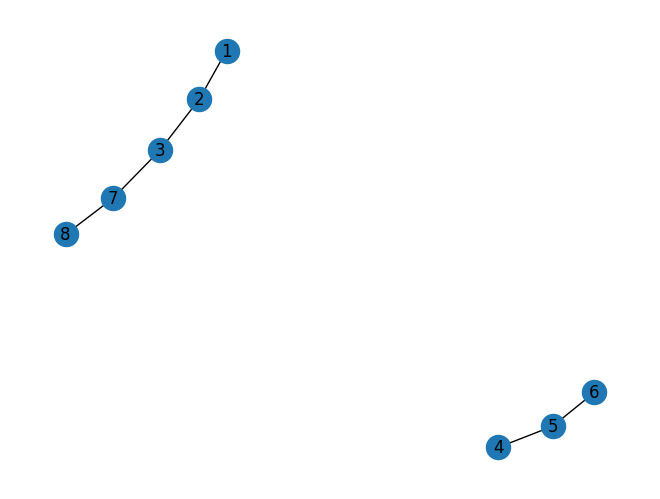

In [101]:
G_connected.remove_edge(3, 4)
check_connectivity(G_connected)

Is connected: False
Number of connected components: 3
Connected components: [{1, 2, 3}, {4, 5, 6}, {8, 7}]


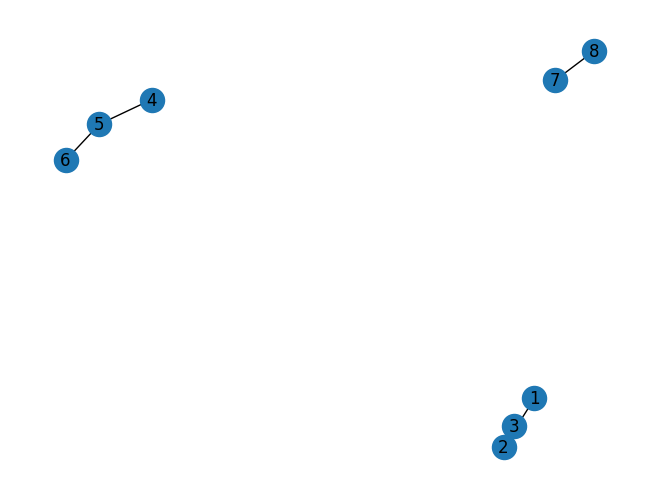

In [102]:
G_connected.remove_edge(3, 7)
check_connectivity(G_connected)

Task 1.6: Connectivity Restoration
Start with a disconnected graph, find the minimum number of edges needed to make it connected

In [106]:
components=list(nx.connected_components(G_connected))
minimum_edges_needed = len(components) - 1

print("Minimum number of edges needed to connect all components:", minimum_edges_needed)

Minimum number of edges needed to connect all components: 2


Task 1.7: Graph Traversal
Implement BFS/DFS from a source vertex. Print the BFS/DFS tree, level of each vertex, and identify cross edges.

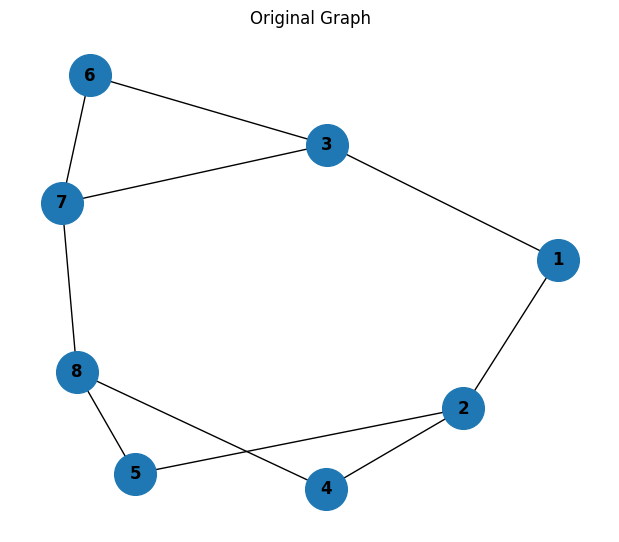

In [108]:

G_traversal = nx.Graph()

G_traversal.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (2, 5),
    (3, 6),
    (3, 7),
    (4, 8),
    (5, 8),
    (6, 7),
    (7, 8)
])

source = 1

plt.figure(figsize=(6, 5))
nx.draw(
    G_traversal,
    with_labels=True,
    node_size=900,
    font_weight='bold'
)
plt.title("Original Graph")
plt.show()

In [111]:
from collections import deque
visited = set()
queue = deque([source])

bfs_tree_edges = []
level = {source: 0}
parent = {source: None}

visited.add(source)

while queue:
    current = queue.popleft()

    for neighbor in G_traversal.neighbors(current):
        if neighbor not in visited:
            visited.add(neighbor)
            queue.append(neighbor)

            parent[neighbor] = current
            level[neighbor] = level[current] + 1
            bfs_tree_edges.append((current, neighbor))

print("BFS Tree Edges:")
print(bfs_tree_edges)

print("\nLevel of Each Vertex in BFS:")
for node in sorted(level):
    print(f"Node {node}: Level {level[node]}")

BFS Tree Edges:
[(1, 2), (1, 3), (2, 4), (2, 5), (3, 6), (3, 7), (4, 8)]

Level of Each Vertex in BFS:
Node 1: Level 0
Node 2: Level 1
Node 3: Level 1
Node 4: Level 2
Node 5: Level 2
Node 6: Level 2
Node 7: Level 2
Node 8: Level 3


In [112]:


all_edges = set(tuple(sorted(edge)) for edge in G_traversal.edges())
tree_edges = set(tuple(sorted(edge)) for edge in bfs_tree_edges)

bfs_cross_edges = all_edges - tree_edges

print("BFS Cross Edges:")
print(bfs_cross_edges)

BFS Cross Edges:
{(6, 7), (7, 8), (5, 8)}


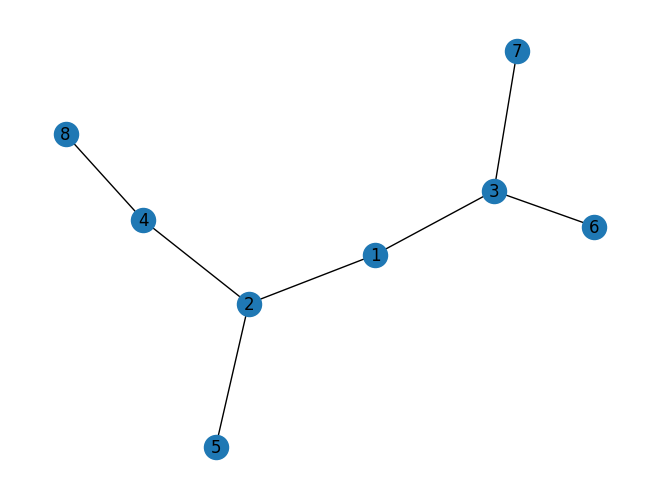

In [113]:


BFS_tree = nx.Graph()
BFS_tree.add_edges_from(bfs_tree_edges)
nx.draw(
    BFS_tree,
    with_labels=True,
)
